# AuraFitness Rest Day Engine Testing

This notebook tests the rule-based rest day suggestion engine.

Important:

- This is not ML training.
- Manual cases are controlled function tests only.
- No fake training dataset is used.
- Later, the React app will pass real user workout history into this engine.

Engine output:

- train
- rest_day
- active_recovery
- avoid_same_muscle
- reduce_intensity

In [1]:
from pathlib import Path
import sys
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

from utils.rest_day_engine import RecentWorkout, RestDayRequest, recommend_rest_day

REPORTS_DIR = AI_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai


## Controlled recovery test cases

These cases test common workout recovery situations.

They are not used for ML training.

In [2]:
test_cases = [
    (
        "Safe to train",
        RestDayRequest(
            today="2026-07-04",
            planned_body_part="chest",
            planned_target_muscle="pectorals",
            recent_workouts=[
                RecentWorkout(
                    workout_date="2026-07-01",
                    body_part="back",
                    target_muscle="lats",
                    workout_volume=12,
                    duration_minutes=45,
                    intensity="moderate",
                )
            ],
            soreness_level=3,
            fatigue_level=3,
            sleep_hours=7.5,
            weekly_workout_count=3,
        ),
    ),
    (
        "Same muscle trained yesterday",
        RestDayRequest(
            today="2026-07-04",
            planned_body_part="chest",
            planned_target_muscle="pectorals",
            recent_workouts=[
                RecentWorkout(
                    workout_date="2026-07-03",
                    body_part="chest",
                    target_muscle="pectorals",
                    workout_volume=16,
                    duration_minutes=55,
                    intensity="moderate",
                )
            ],
            soreness_level=4,
            fatigue_level=4,
            sleep_hours=7,
            weekly_workout_count=4,
        ),
    ),
    (
        "High soreness and low sleep",
        RestDayRequest(
            today="2026-07-04",
            planned_body_part="upper legs",
            planned_target_muscle="quads",
            recent_workouts=[
                RecentWorkout(
                    workout_date="2026-07-03",
                    body_part="upper legs",
                    target_muscle="quads",
                    workout_volume=24,
                    duration_minutes=70,
                    intensity="high",
                )
            ],
            soreness_level=8,
            fatigue_level=7,
            sleep_hours=4.5,
            weekly_workout_count=5,
        ),
    ),
    (
        "Planned rest day",
        RestDayRequest(
            today="2026-07-04",
            planned_body_part="back",
            planned_target_muscle="lats",
            recent_workouts=[],
            planned_rest_day=True,
            soreness_level=3,
            fatigue_level=3,
            sleep_hours=8,
            weekly_workout_count=4,
        ),
    ),
    (
        "Invalid soreness input",
        RestDayRequest(
            today="2026-07-04",
            planned_body_part="shoulders",
            planned_target_muscle="delts",
            recent_workouts=[],
            soreness_level=15,
            fatigue_level=5,
            sleep_hours=7,
            weekly_workout_count=3,
        ),
    ),
]

## Run rest day recommendations

This cell runs the rule-based recovery engine and stores the outputs.

In [3]:
rows = []

for title, request in test_cases:
    recommendation = recommend_rest_day(request)

    rows.append({
        "test_case": title,
        "planned_body_part": request.planned_body_part,
        "planned_target_muscle": request.planned_target_muscle,
        "soreness_level": request.soreness_level,
        "fatigue_level": request.fatigue_level,
        "sleep_hours": request.sleep_hours,
        "weekly_workout_count": request.weekly_workout_count,
        **asdict(recommendation),
    })

results_df = pd.DataFrame(rows)
display(results_df)

,test_case,planned_body_part,planned_target_muscle,soreness_level,fatigue_level,sleep_hours,weekly_workout_count,action,title,message,confidence,risk_score,reason_codes
0,Safe to train,chest,pectorals,3,3,7.5,3,train,You can train today,Recovery risk looks acceptable. Train as plann...,0.72,0,[]
1,Same muscle trained yesterday,chest,pectorals,4,4,7.0,4,avoid_same_muscle,Avoid the same muscle group,You trained pectorals recently. Choose a diffe...,0.82,35,[same_target_muscle_trained_within_24h]
2,High soreness and low sleep,upper legs,quads,8,7,4.5,5,rest_day,Take a rest day,Your recovery risk is high today. Take a prope...,0.90,165,"[high_soreness, moderate_fatigue, very_low_sle..."
3,Planned rest day,back,lats,3,3,8.0,4,rest_day,Follow your planned rest day,Today is already planned as a rest day. Take t...,0.92,40,[planned_rest_day]
4,Invalid soreness input,shoulders,delts,15,5,7.0,3,reduce_intensity,Check recovery inputs,Some recovery values look invalid or unusual. ...,0.60,50,[soreness_out_of_range]


## Chart rest day actions

This chart shows which recovery action the engine selected.

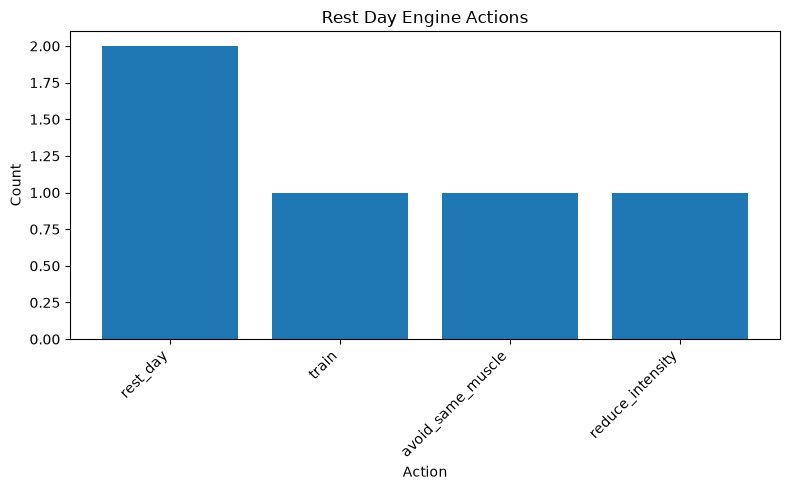

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\rest_day_engine_actions.png


In [4]:
action_counts = results_df["action"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(action_counts.index, action_counts.values)
plt.title("Rest Day Engine Actions")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "rest_day_engine_actions.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart recovery risk score

This chart shows the recovery risk score for each controlled case.

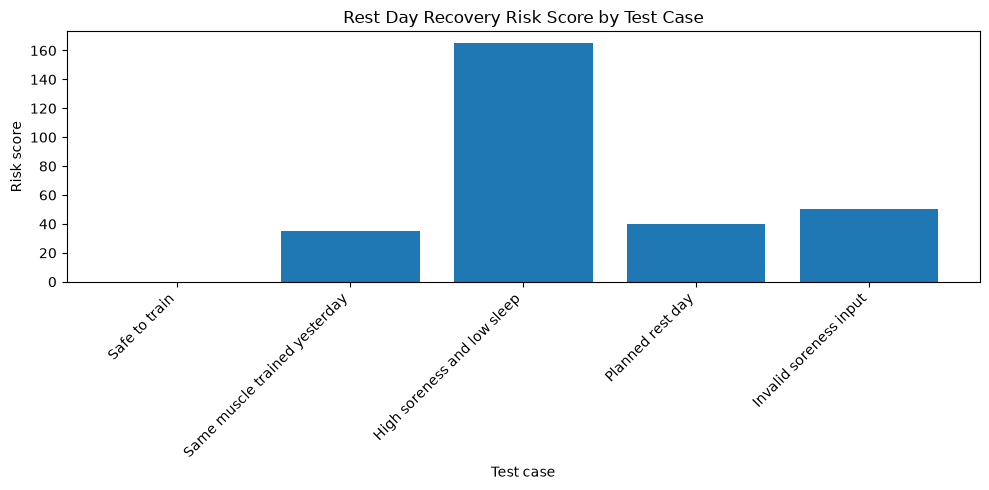

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\rest_day_engine_risk_scores.png


In [5]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["test_case"], results_df["risk_score"])
plt.title("Rest Day Recovery Risk Score by Test Case")
plt.xlabel("Test case")
plt.ylabel("Risk score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "rest_day_engine_risk_scores.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart confidence by test case

This chart shows the confidence score for each recovery decision.

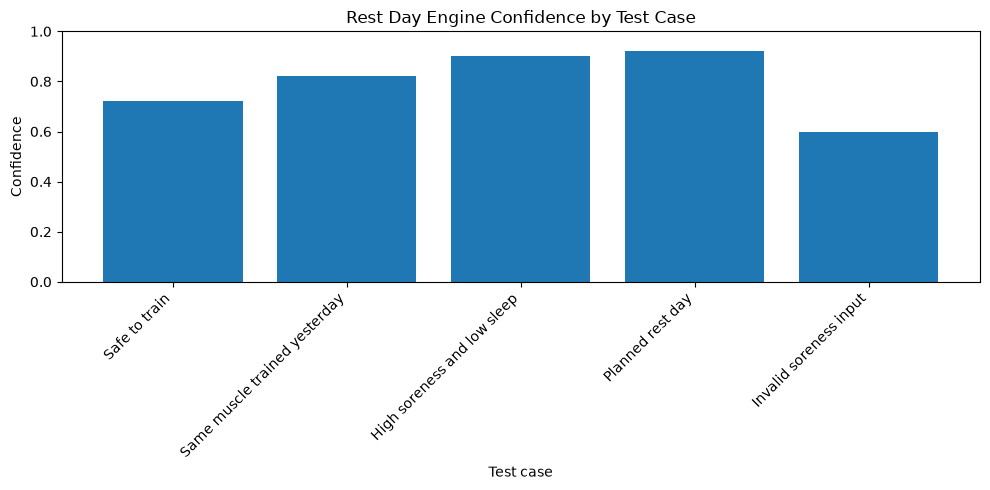

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\rest_day_engine_confidence.png


In [6]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["test_case"], results_df["confidence"])
plt.title("Rest Day Engine Confidence by Test Case")
plt.xlabel("Test case")
plt.ylabel("Confidence")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "rest_day_engine_confidence.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Save rest day engine test results

This saves the logic verification results for documentation.

In [7]:
output_path = REPORTS_DIR / "rest_day_engine_test_results.csv"
results_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\rest_day_engine_test_results.csv


## Product behavior review

The planned rest day case should return `rest_day` directly.

Reason:

A planned rest day is a schedule decision, not only a recovery-risk threshold.

Expected result:

- Action: `rest_day`
- Reason code: `planned_rest_day`

In [8]:
planned_rest_row = results_df[results_df["test_case"] == "Planned rest day"].iloc[0]

if planned_rest_row["action"] != "rest_day":
    raise ValueError("Planned rest day should return rest_day.")

if "planned_rest_day" not in planned_rest_row["reason_codes"]:
    raise ValueError("Expected planned_rest_day reason code.")

print("Planned rest day product behavior check passed.")

Planned rest day product behavior check passed.
